# Configuration

In [3]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.interpolate import UnivariateSpline, CubicSpline
from patsy import dmatrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Simulation

The true means are drawn from an exponential distribution:
$$
\mu_i \sim \exp(1)
$$

Each observation is drawn from a normal distribution with the same and known variance:
$$
z_i \sim \mathcal{N}(\mu_i, \sigma^2)
$$

In [2]:
np.random.seed(42)
N = 5000  # Number of observations
# mu_true = np.random.exponential(scale=1, size=N)  # True means
mu_true = np.repeat(-np.log((np.arange(1, 501, 1) - 0.5) / 500), 10)
sigma = 1  # Known standard deviation
z = np.random.normal(loc=mu_true, scale=sigma, size=N)  # Observed data

# Model

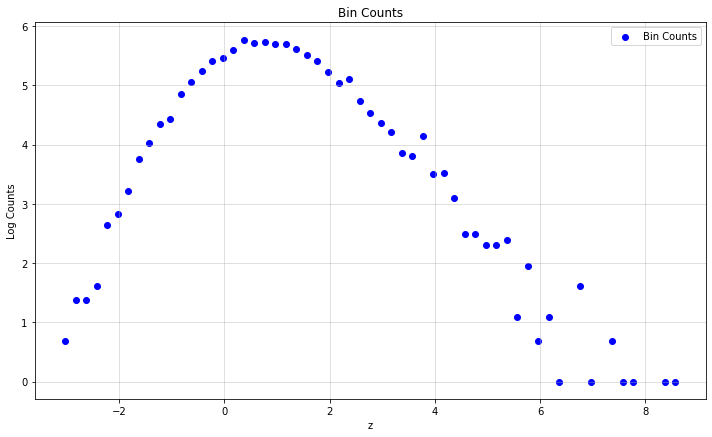

In [3]:
bin_width = 0.2
bins = np.arange(min(z), max(z) + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2
counts, _ = np.histogram(z, bins=bins)

fig, ax = plt.subplots(figsize=(10, 6.18))
ax.scatter(bin_centers[counts!=0], np.log(counts[counts!=0]), color='blue', label='Bin Counts')
ax.set_xlabel("z")
ax.set_ylabel("Log Counts")
ax.set_title("Bin Counts")
ax.grid(True, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

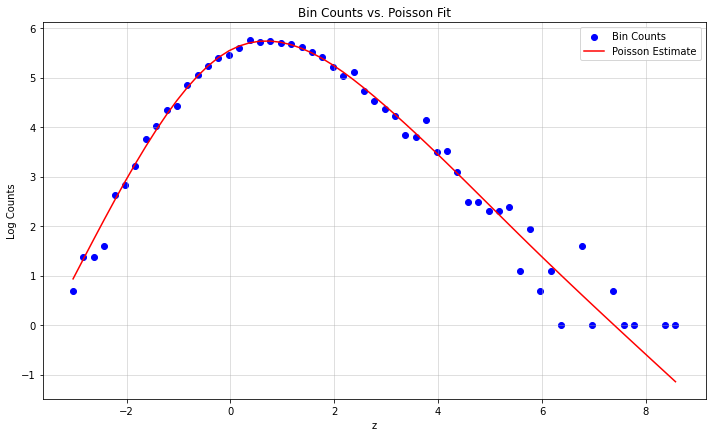

In [4]:
# Step 2: Poisson Regression for Log-density Estimation
transformed_x = dmatrix("cr(x, df=5)", {'x': bin_centers}, return_type='dataframe')

model = sm.GLM(counts, transformed_x, family=sm.families.Poisson())
result = model.fit()

log_density_estimate = np.log(result.predict(transformed_x))

fig, ax = plt.subplots(figsize=(10, 6.18))
ax.scatter(bin_centers[counts!=0], np.log(counts[counts!=0]), color='blue', label='Bin Counts')
ax.plot(bin_centers, log_density_estimate, color='red', label='Poisson Estimate')
ax.set_xlabel("z")
ax.set_ylabel("Log Counts")
ax.set_title("Bin Counts vs. Poisson Fit")
ax.grid(True, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

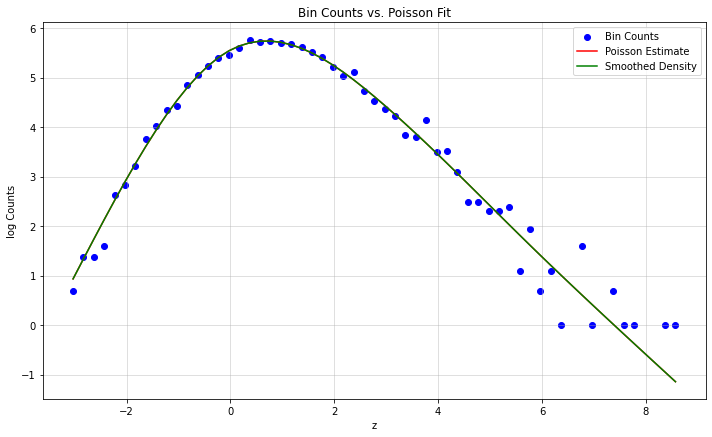

In [5]:
# Step 3: Smooth Log-density with Splines
spline = CubicSpline(bin_centers, log_density_estimate, bc_type='natural')
spline_approx = spline(bin_centers)

fig, ax = plt.subplots(figsize=(10, 6.18))
ax.scatter(bin_centers[counts!=0], np.log(counts[counts!=0]), color='blue', label='Bin Counts')
ax.plot(bin_centers, log_density_estimate, color='red', label='Poisson Estimate')
ax.plot(bin_centers, spline_approx, color='green', label='Smoothed Density')
ax.set_xlabel("z")
ax.set_ylabel("log Counts")
ax.set_title("Bin Counts vs. Poisson Fit")
ax.grid(True, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Step 4: Apply Tweedie's Formula
log_density_derivative = spline.derivative()(z)
bayes_correction = sigma**2 * log_density_derivative
mu_posterior = z + bayes_correction

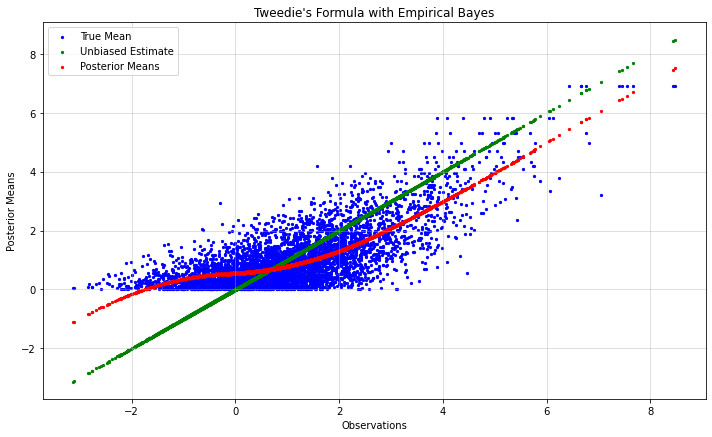

In [7]:
# Plot results
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.scatter(z, mu_true, color='blue', s=5, label='True Mean')
ax.scatter(z, z, color='green', s=5, label="Unbiased Estimate")
ax.scatter(z, mu_posterior, color="red", s=5, label="Posterior Means")
ax.set_xlabel("Observations")
ax.set_ylabel("Posterior Means")
ax.legend()
ax.grid(True, alpha=0.5)
ax.set_title("Tweedie's Formula with Empirical Bayes")

plt.tight_layout()
plt.show()

In [8]:
class EmpiricalBayes(object):
    def __init__(self, dof: int = 5, bin_width: float = 0.2, sigma: float = None):
        self.dof = dof
        self.bin_width = bin_width

        # initialize attributes
        self.spline = None
        self.std_est = sigma

    def fit(self, x: np.ndarray):
        # Step 0: estimate sigma
        self.std_est = np.std(x) if self.std_est is None else self.std_est

        # Step 1: Bin data for Poisson regression
        bins = np.arange(min(x), max(x) + self.bin_width, self.bin_width)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        counts, _ = np.histogram(x, bins=bins)

        # Step 2: Poisson Regression for Log-density Estimation
        exog = dmatrix(f"cr(x, df={self.dof})", {'x': bin_centers}, return_type='dataframe')
        model = sm.GLM(counts, exog, family=sm.families.Poisson()).fit()
        log_counts_est = np.log(model.predict(exog))
        # Step 3:
        self.spline = CubicSpline(bin_centers, log_counts_est, bc_type='natural')

        return self

    def predict(self, x: np.ndarray):
        # Apply Tweedie's Formula
        log_density_derivative = self.spline.derivative()(x)
        bayes_correction = self.std_est**2 * log_density_derivative

        return x + bayes_correction

# Experiments

## Efron 2011 JASA

In [9]:
def simulate_efron2011(sample_size: int = 5000, std: float = 1) -> tuple:
    mu_arr = np.random.exponential(scale=1, size=sample_size)
    # mu_arr = np.concatenate([[1] * 2500, [1.5] * 2500])
    # mu_arr = np.repeat(-np.log((np.arange(1, 501, 1) - 0.5) / 500), 10)  # Eq. 3.4 from paper
    z_arr = np.random.normal(loc=mu_arr, scale=std, size=sample_size)
    return z_arr, mu_arr

In [10]:
# generate data
z_arr, mu_arr = simulate_efron2011()

# empirical bayes estimate
emp_bayes = EmpiricalBayes(dof=5, bin_width=0.2, sigma=1).fit(z_arr)
z_post_arr = emp_bayes.predict(z_arr)

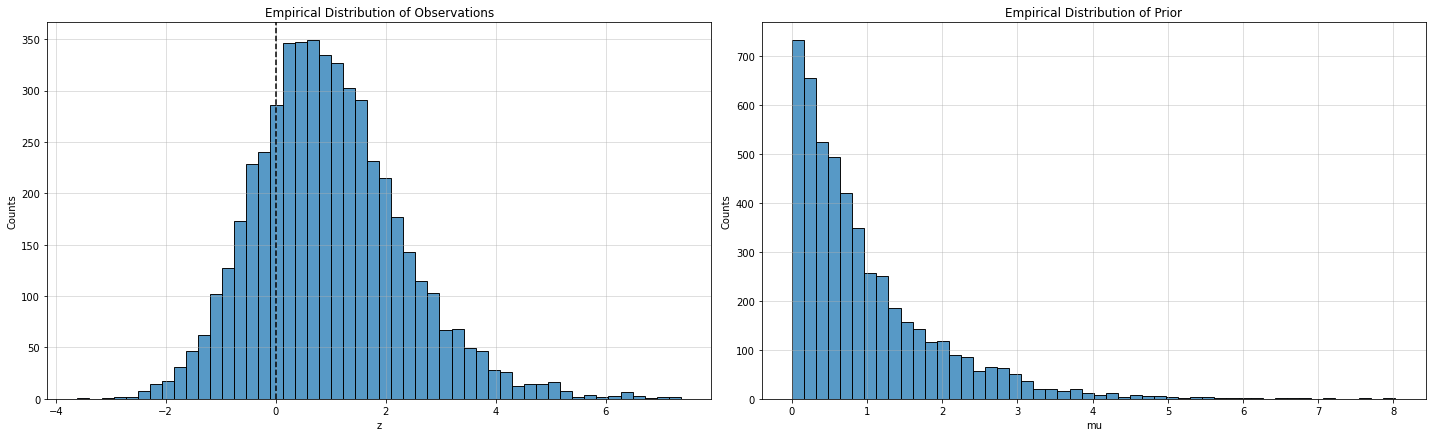

In [11]:
# histogram
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# histogram of the z's
sns.histplot(z_arr, bins=50, stat='count', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--')

axes[0].set_xlabel("z")
axes[0].set_ylabel("Counts")
axes[0].grid(True, alpha=0.5)
axes[0].set_title("Empirical Distribution of Observations")

# histogram of the mu's
sns.histplot(mu_arr, bins=50, stat='count', ax=axes[1])
# axes[1].axvline(0, color='black', linestyle='--')

axes[1].set_xlabel("mu")
axes[1].set_ylabel("Counts")
axes[1].grid(True, alpha=0.5)
axes[1].set_title("Empirical Distribution of Prior")

plt.tight_layout()
plt.show()

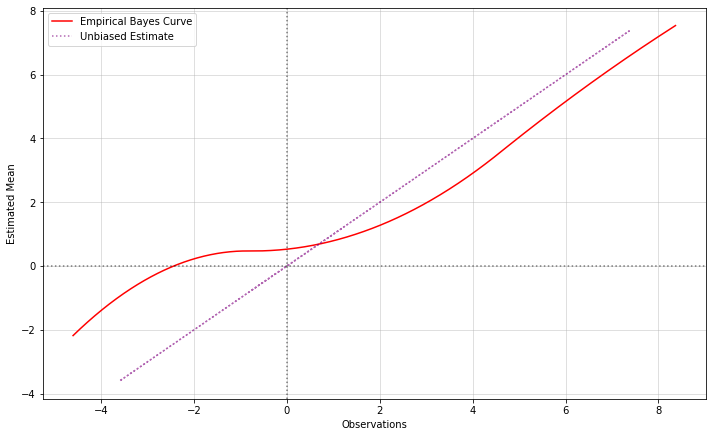

In [12]:
# empirical Bayes estimate
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_z_arr = np.linspace(z_arr.min() - 1, z_arr.max() + 1, 1000)
ax.plot(viz_z_arr, emp_bayes.predict(viz_z_arr), color='red', label='Empirical Bayes Curve')

# plot diagonal line
ax.plot(z_arr, z_arr, color='purple', linestyle='dotted', alpha=0.6, label='Unbiased Estimate')

ax.axvline(0, color='black', linestyle='dotted', alpha=0.5)
ax.axhline(0, color='black', linestyle='dotted', alpha=0.5)

ax.set_xlabel("Observations")
ax.set_ylabel("Estimated Mean")
ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [00:04<00:00, 249.91it/s]


Winner's Curse of no correction: 1.0079 (0.0142)
Winner's Curse of empirical Bayes: 0.0941 (0.0144)


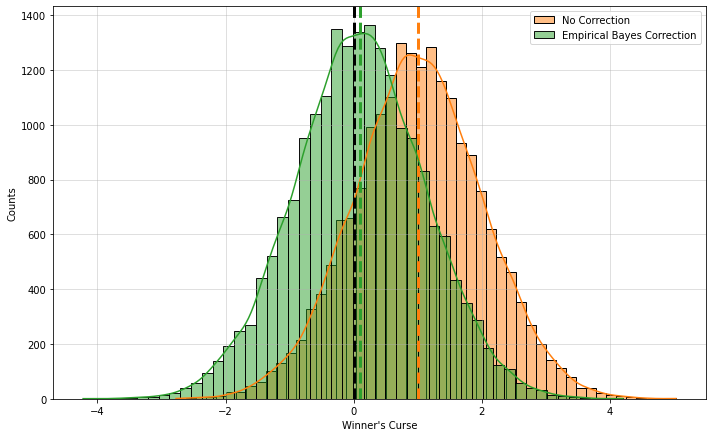

In [13]:
n_repeats = 1000
top_k = 20  # default to 20

nc_wc_list = [None] * n_repeats
eb_wc_list = [None] * n_repeats

aggregation = 'concatenate'
aggregation_dict = {
    'concatenate': np.concatenate,
    'sum': lambda list_: [np.sum(item) for item in list_],
    'mean': lambda list_: [np.mean(item) for item in list_],
}

for idx in tqdm(range(n_repeats)):
    # simulate
    z_arr, mu_arr = simulate_efron2011(sample_size=5000)

    # fit empirical bayes
    emp_bayes = EmpiricalBayes(dof=5, bin_width=0.2, sigma=1).fit(z_arr)
    z_post_arr = emp_bayes.predict(z_arr)

    selection_idx = np.argsort(z_post_arr)[-top_k:]

    eb_wc_list[idx] = z_post_arr[selection_idx] - mu_arr[selection_idx]
    nc_wc_list[idx] = z_arr[selection_idx] - mu_arr[selection_idx]

nc_wc_arr = aggregation_dict[aggregation](nc_wc_list)
eb_wc_arr = aggregation_dict[aggregation](eb_wc_list)

nc_wc_avg = np.mean(nc_wc_arr)
nc_wc_se = np.std(nc_wc_arr) / np.sqrt(5000)

eb_wc_avg = np.mean(eb_wc_arr)
eb_wc_se = np.std(eb_wc_arr) / np.sqrt(5000)

print(f"Winner's Curse of no correction: {nc_wc_avg:.4f} ({nc_wc_se:.4f})")
print(f"Winner's Curse of empirical Bayes: {eb_wc_avg:.4f} ({eb_wc_se:.4f})")

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot the histogram of the largests
sns.histplot(nc_wc_arr, bins=50, stat='count', ax=ax, kde=True, color='C1', label='No Correction')
ax.axvline(nc_wc_avg, color='C1', linestyle='--', linewidth=3)

sns.histplot(eb_wc_arr, bins=50, stat='count', ax=ax, kde=True, color='C2', label='Empirical Bayes Correction')
ax.axvline(eb_wc_avg, color='C2', linestyle='--', linewidth=3)

ax.set_xlabel("Winner's Curse")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.5)
ax.legend()
ax.axvline(0, color='black', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

## Treatment Selection

In [20]:
tau_arr = np.array([1, 1.1])
sigma = 1
sample_size = 1000
propensity_arr = np.array([0.5, 0.5])

n_treatments = len(tau_arr)

treatment_arr = np.random.choice(np.arange(len(tau_arr)), size=sample_size, p=propensity_arr)
outcome_arr = np.random.normal(loc=tau_arr[treatment_arr], scale=sigma, size=sample_size)

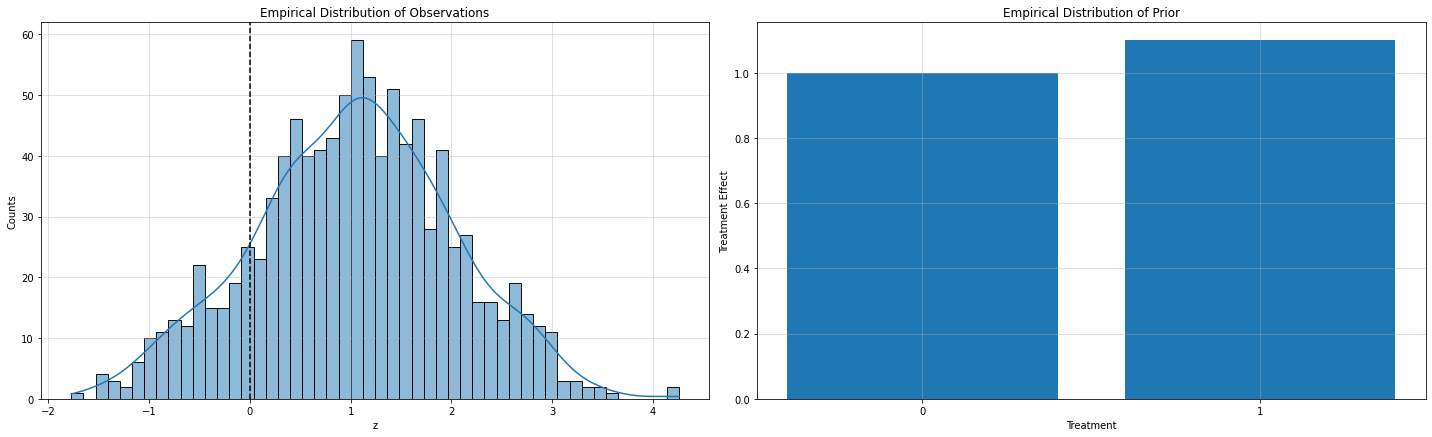

In [21]:
# histogram
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# histogram of the outcomes
sns.histplot(outcome_arr, bins=50, stat='count', ax=axes[0], kde=True)
axes[0].axvline(0, color='black', linestyle='--')

axes[0].set_xlabel("z")
axes[0].set_ylabel("Counts")
axes[0].grid(True, alpha=0.5)
axes[0].set_title("Empirical Distribution of Observations")

# histogram of the actual treatment effect
axes[1].bar(np.arange(len(tau_arr)), tau_arr,)

axes[1].set_xlabel("Treatment")
axes[1].set_xticks(np.arange(len(tau_arr)))
axes[1].set_ylabel("Treatment Effect")
axes[1].grid(True, alpha=0.5)
axes[1].set_title("Empirical Distribution of Prior")

plt.tight_layout()
plt.show()

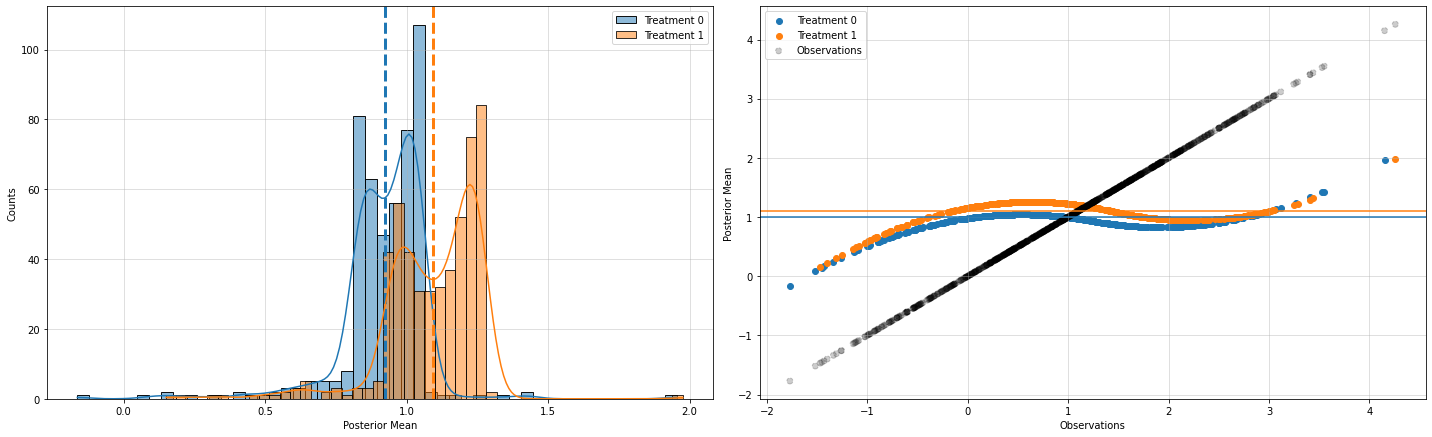

In [22]:
# group based empirical Bayes estimation
tau_group_post_dstn_arr = np.zeros(treatment_arr.shape[0])
tau_group_post_arr = np.zeros(n_treatments)

for idx in range(n_treatments):
    emp_bayes = EmpiricalBayes(dof=3, bin_width=0.2, sigma=1).fit(outcome_arr[treatment_arr == idx])
    tau_group_post_dstn_arr[treatment_arr == idx] = emp_bayes.predict(outcome_arr[treatment_arr == idx])
    tau_group_post_arr[idx] = np.mean(tau_group_post_dstn_arr[treatment_arr == idx])

fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# plot the posterior mean for each observation
for idx in range(n_treatments):
    sns.histplot(tau_group_post_dstn_arr[treatment_arr == idx], bins=50, stat='count', ax=axes[0], kde=True, color=f'C{idx}', label=f'Treatment {idx}')
    axes[0].axvline(tau_group_post_arr[idx], color=f'C{idx}', linestyle='--', linewidth=3)

axes[0].set_xlabel("Posterior Mean")
axes[0].set_ylabel("Counts")

#
for idx in range(n_treatments):
    axes[1].scatter(outcome_arr[treatment_arr == idx], tau_group_post_dstn_arr[treatment_arr == idx], color=f'C{idx}', label=f'Treatment {idx}')
    axes[1].axhline(tau_arr[idx], color=f'C{idx}')

axes[1].set_xlabel("Observations")
axes[1].set_ylabel("Posterior Mean")

axes[1].scatter(outcome_arr, outcome_arr, color='black', linestyle='--', alpha=0.2, label='Observations')

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

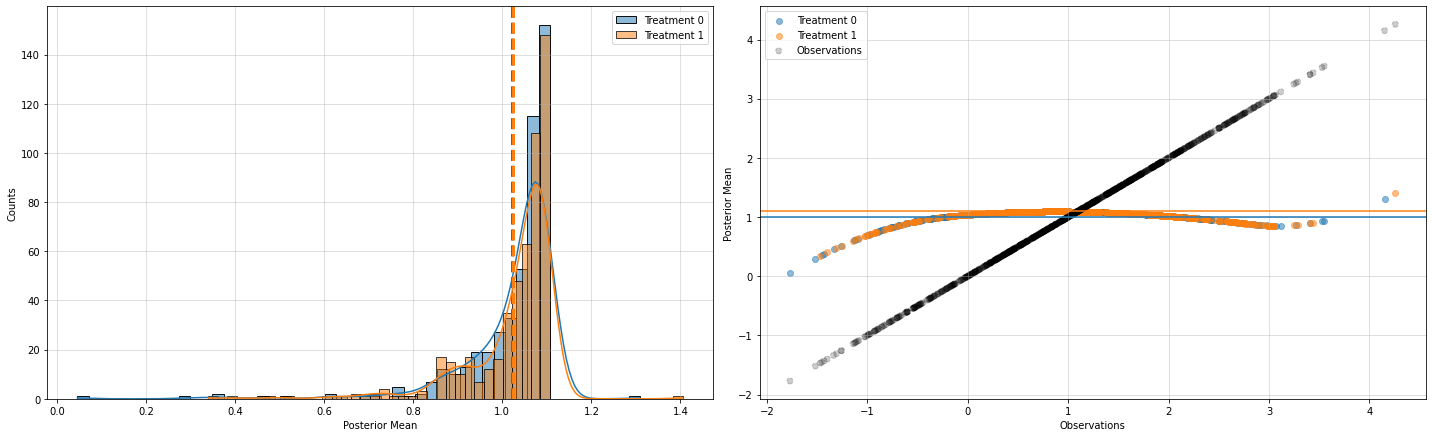

In [23]:
# empirical bayes estimation
emp_bayes = EmpiricalBayes(dof=5, bin_width=0.2, sigma=1).fit(outcome_arr)
tau_post_dstn_arr = emp_bayes.predict(outcome_arr)
tau_post_arr = np.array([np.mean(tau_post_dstn_arr[treatment_arr == idx]) for idx in range(n_treatments)])

fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# plot the posterior mean for each observation
for idx in range(n_treatments):
    sns.histplot(tau_post_dstn_arr[treatment_arr == idx], bins=50, stat='count', ax=axes[0], kde=True, color=f'C{idx}', label=f'Treatment {idx}')
    axes[0].axvline(tau_post_arr[idx], color=f'C{idx}', linestyle='--', linewidth=3)

axes[0].set_xlabel("Posterior Mean")
axes[0].set_ylabel("Counts")

#
for idx in range(n_treatments):
    axes[1].scatter(outcome_arr[treatment_arr == idx], tau_post_dstn_arr[treatment_arr == idx], color=f'C{idx}', alpha=0.5, label=f'Treatment {idx}')
    axes[1].axhline(tau_arr[idx], color=f'C{idx}')

axes[1].scatter(outcome_arr, outcome_arr, color='black', linestyle='--', alpha=0.2, label='Observations')

axes[1].set_xlabel("Observations")
axes[1].set_ylabel("Posterior Mean")

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# frequentist's estimation: simple average
tau_est_arr = np.array([
    np.mean(outcome_arr[treatment_arr == idx]) for idx in range(n_treatments)
])

In [25]:
for tau_true, tau_est, tau_group_post, tau_post in zip(tau_arr, tau_est_arr, tau_group_post_arr, tau_post_arr):
    print(f"True: {tau_true:.4f}, Estimated: {tau_est:.4f}, Group-based EB: {tau_group_post:.4f}, EB: {tau_post:.4f}")

True: 1.0000, Estimated: 0.9322, Group-based EB: 0.9228, EB: 1.0221
True: 1.1000, Estimated: 1.1231, Group-based EB: 1.0943, EB: 1.0251


100%|██████████| 5000/5000 [00:36<00:00, 137.59it/s]


Winner's Curse of no correction: 72.59% (12.44%)
Winner's Curse of group-based empirical Bayes: 8.30% (231.29%)
Winner's Curse of empirical Bayes: -12.84% (106.32%)


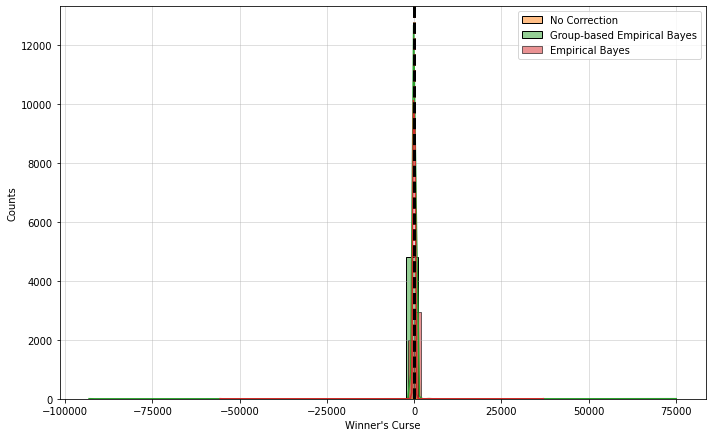

In [26]:
n_repeats = 5000
tau_arr = np.array([1, 1.1])
sigma = 1
sample_size = 100
propensity_arr = np.array([0.5, 0.5])

n_treatments = len(tau_arr)
delta_tau = tau_arr[1] - tau_arr[0]

nc_wc_arr = np.zeros(n_repeats)
group_eb_wc_arr = np.zeros(n_repeats)
eb_wc_arr = np.zeros(n_repeats)


for idx in tqdm(range(n_repeats)):
    # simulate
    treatment_arr = np.random.choice(np.arange(len(tau_arr)), size=sample_size, p=propensity_arr)
    outcome_arr = np.random.normal(loc=tau_arr[treatment_arr], scale=sigma, size=sample_size)

    # no correction
    tau_est_arr = np.array([
        np.mean(outcome_arr[treatment_arr == idx]) for idx in range(n_treatments)
    ])
    selected_treatment = np.argmax(tau_est_arr)
    nc_wc_arr[idx] = tau_est_arr[selected_treatment] - tau_arr[selected_treatment]

    # fit group-based empirical bayes
    with warnings.catch_warnings():
        warnings.filterwarnings('error')
        try:
            tau_group_post_arr = np.zeros(n_treatments)
            for j in range(n_treatments):
                emp_bayes = EmpiricalBayes(dof=3, bin_width=0.2, sigma=1).fit(outcome_arr[treatment_arr == j])
                tau_group_post_arr[j] = np.mean(emp_bayes.predict(outcome_arr[treatment_arr == j]))
        except ValueError:
            group_eb_wc_arr[idx] = np.nan
        except RuntimeWarning:
            group_eb_wc_arr[idx] = np.nan
        else:
            group_eb_wc_arr[idx] = tau_group_post_arr[selected_treatment] - tau_arr[selected_treatment]

    # fit empirical bayes
    with warnings.catch_warnings():
        warnings.filterwarnings('error')
        try:
            emp_bayes = EmpiricalBayes(dof=5, bin_width=0.2, sigma=1).fit(outcome_arr)
            tau_post_arr = emp_bayes.predict(outcome_arr)
            tau_post_arr = np.array([np.mean(tau_post_arr[treatment_arr == idx]) for idx in range(n_treatments)])
        except ValueError:
            eb_wc_arr[idx] = np.nan
        except RuntimeWarning:
            eb_wc_arr[idx] = np.nan
        else:
            eb_wc_arr[idx] = tau_post_arr[selected_treatment] - tau_arr[selected_treatment]

# remove None's
nc_wc_arr = 100 * nc_wc_arr[~np.isnan(nc_wc_arr)] / delta_tau
group_eb_wc_arr = 100 * group_eb_wc_arr[~np.isnan(group_eb_wc_arr)] / delta_tau
eb_wc_arr = 100 * eb_wc_arr[~np.isnan(eb_wc_arr)] / delta_tau

nc_wc_avg = np.mean(nc_wc_arr)
nc_wc_se = np.std(nc_wc_arr) / np.sqrt(sample_size)

group_eb_wc_avg = np.mean(group_eb_wc_arr)
group_eb_wc_se = np.std(group_eb_wc_arr) / np.sqrt(sample_size)

eb_wc_avg = np.mean(eb_wc_arr)
eb_wc_se = np.std(eb_wc_arr) / np.sqrt(sample_size)

print(f"Winner's Curse of no correction: {nc_wc_avg:.2f}% ({nc_wc_se:.2f}%)")
print(f"Winner's Curse of group-based empirical Bayes: {group_eb_wc_avg:.2f}% ({group_eb_wc_se:.2f}%)")
print(f"Winner's Curse of empirical Bayes: {eb_wc_avg:.2f}% ({eb_wc_se:.2f}%)")

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot the histogram of the largests
sns.histplot(nc_wc_arr, bins=50, stat='count', ax=ax, kde=True, color='C1', label='No Correction')
ax.axvline(nc_wc_avg, color='C1', linestyle='--', linewidth=3)

sns.histplot(group_eb_wc_arr, bins=50, stat='count', ax=ax, kde=True, color='C2', label='Group-based Empirical Bayes')
ax.axvline(group_eb_wc_avg, color='C2', linestyle='--', linewidth=3)

sns.histplot(eb_wc_arr, bins=50, stat='count', ax=ax, kde=True, color='C3', label='Empirical Bayes')
ax.axvline(eb_wc_avg, color='C3', linestyle='--', linewidth=3)

ax.set_xlabel("Winner's Curse")
ax.set_ylabel("Counts")
ax.grid(True, alpha=0.5)
ax.legend()
ax.axvline(0, color='black', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()